# Parametric PINN — n-DOF Impact-Damper Chain

This notebook trains **one** neural network that covers a range of physical
parameters simultaneously using Latin-Hypercube Sampling (LHS).  After a
single training run the network predicts the response for **any** parameter
combination within the sampled range without retraining.

**Varied parameters (LHS-sampled per case)**

| Symbol | Meaning | Range |
|--------|---------|-------|
| `mx`   | primary mass | [0.5, 2.0] |
| `my`   | impactor mass | [0.1, 0.5] |
| `k`    | spring stiffness | [0.5, 2.0] |
| `phi1` | forcing amplitude | [5.0, 20.0] |
| `phi2` | forcing frequency coeff | [1.0, 4.0] |

**Fixed**

| Symbol | Value | Meaning |
|--------|-------|---------|
| `n_dof` | 5 | number of DOFs / impactors |
| `c`     | 0 | proportional damping (undamped) |
| `D`     | 1.0 | impact gap |
| `r`     | 1.0 | coefficient of restitution |

**Workflow**
1. LHS-sample `n_cases` parameter sets
2. Build `ParametricPIPNNs` (one network, all cases)
3. Train on ODE + IC loss
4. Root-find impact times per case
5. Propagate ICs → next segment
6. Repeat for `n_segments`
7. Save results for dispersion analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os, sys
import scipy.io
from pathlib import Path

# ── Import parametric PINN ────────────────────────────────────────────────
nb_dir = Path.cwd().resolve()
if nb_dir.name != 'parametric_PINN_ndofs':
    alt = nb_dir / 'parametric_PINN_ndofs'
    if alt.exists():
        nb_dir = alt
sys.path.insert(0, str(nb_dir))
from pinn_ndof_chain_parametric_tf2 import (
    lhs_sample,
    ParametricPIPNNs,
    find_impact_times_parametric,
    propagate_ics_parametric,
    rollout_full_sequence_with_model_pool,
    newmark_beta,
)

import tensorflow as tf
print('TF version:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))


/opt/anaconda3/envs/tf2/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


TF version: 2.16.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Fixed system parameters

In [2]:
# ── Fixed ────────────────────────────────────────────────────────────────
n_dof = 5      # number of primary DOFs / impactors
c     = 0.0    # proportional damping (0 = undamped)
D     = 1.0    # impact gap (same for all DOFs)
r     = 1.0    # coefficient of restitution

# Choose which physical parameters are parametric inputs to the PINN
parametric_params = ['phi1', 'phi2']

# Bounds for ONLY the selected parametric parameters (same order)
lb_params = np.array([10.0, 1.0], dtype=np.float32)
ub_params = np.array([20.0, 2.0], dtype=np.float32)

# Fixed values for non-parametric physical parameters
fixed_params = {
    'mx': 1.0,
    'my': 0.3,
    'k':  1.0,
}

print('Parametric inputs:', parametric_params)
print('Bounds for parametric inputs:')
for name, lo, hi in zip(parametric_params, lb_params, ub_params):
    print(f'  {name:6s}: [{lo:.2f}, {hi:.2f}]')
print('Fixed physical parameters:', fixed_params)


Parameter bounds:
  mx    : [1.00, 1.00]
  my    : [0.30, 0.30]
  k     : [1.00, 1.00]
  phi1  : [10.00, 20.00]
  phi2  : [1.00, 2.00]


## LHS sampling of parameter space


LHS sample  (1000 cases × 5 parameters)
        mx        my         k      phi1      phi2
  Case  0:   0.9996    0.3007    0.9996   11.5430    1.9569
  Case  1:   1.0005    0.3006    1.0004   14.4987    1.7465
  Case  2:   0.9995    0.3009    0.9991   11.1018    1.7166
  Case  3:   1.0008    0.2997    1.0006   11.7517    1.8814
  Case  4:   0.9990    0.2993    0.9995   17.4811    1.2382
  Case  5:   1.0005    0.2991    0.9999   12.2485    1.6303
  Case  6:   1.0002    0.2996    0.9997   17.7263    1.4555
  Case  7:   1.0008    0.2997    0.9994   11.8377    1.1953
  Case  8:   0.9993    0.2992    0.9994   14.5869    1.0802
  Case  9:   0.9993    0.2995    1.0001   17.8232    1.1539
  Case 10:   0.9996    0.3003    0.9991   15.5334    1.1073
  Case 11:   1.0007    0.2994    1.0004   14.4186    1.3919
  Case 12:   0.9996    0.2993    0.9992   15.4024    1.3194
  Case 13:   1.0001    0.2999    1.0003   18.1297    1.0966
  Case 14:   0.9994    0.3006    1.0009   12.3677    1.1999
  Case 1

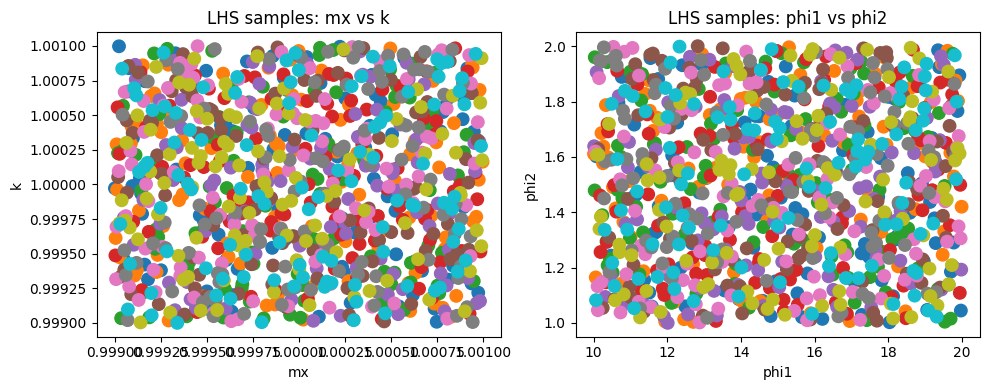

In [3]:
n_cases = 1000     # simultaneous parameter cases (increase for richer coverage)

# Active (network) parameter samples
params_cases = lhs_sample(n_cases, lb_params, ub_params, seed=42).astype(np.float32)

# Reconstruct full physical rows [mx, my, k, phi1, phi2] for analysis/plots
full_param_names = ['mx', 'my', 'k', 'phi1', 'phi2']
params_cases_full = np.zeros((n_cases, len(full_param_names)), dtype=np.float32)
for i, name in enumerate(full_param_names):
    if name in fixed_params:
        params_cases_full[:, i] = float(fixed_params[name])
    else:
        params_cases_full[:, i] = params_cases[:, parametric_params.index(name)]

print(f'\nLHS sample ({n_cases} cases × {len(parametric_params)} active parameters)')
header = '  ' + '  '.join(f'{n:>8s}' for n in parametric_params)
print(header)
for j, row in enumerate(params_cases[:10]):
    vals = '  '.join(f'{v:8.4f}' for v in row)
    print(f'  Case {j:2d}: {vals}')

# ── Scatter plot of sampled parametric dimensions ────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
if len(parametric_params) >= 2:
    ax.scatter(params_cases[:, 0], params_cases[:, 1], c=np.arange(n_cases), cmap='viridis', s=12)
    ax.set_xlabel(parametric_params[0])
    ax.set_ylabel(parametric_params[1])
    ax.set_title(f'LHS samples: {parametric_params[0]} vs {parametric_params[1]}')
else:
    ax.hist(params_cases[:, 0], bins=30)
    ax.set_xlabel(parametric_params[0])
    ax.set_title(f'LHS samples: {parametric_params[0]}')
ax.grid(True, alpha=0.3)
plt.tight_layout()


## Network and training hyper-parameters

In [4]:
# Network: input dim = 1(t) + n_parametric
num_neurons = 64
layers = [1 + len(parametric_params), num_neurons, num_neurons, n_dof]

hyp_ini_weight_loss = np.array([1.0, 1.0])   # [beta_ic, beta_ode]
optimizer_LB_value  = True                    # run L-BFGS-B after Adam

# Segment settings
T_seg      = 1.0     # time window per segment (s)
N_col      = 1000    # collocation points per case
nIter_seg  = 1000    # Adam iterations per segment
n_segments = 2       # number of impact segments

print(f'Network architecture: {layers}')
print(f'Parameters/segment:   n_cases={n_cases}, N_col={N_col}, nIter={nIter_seg}')
print(f'Segments to simulate: {n_segments}')


Network architecture: [6, 64, 64, 5]
Parameters/segment:   n_cases=1000, N_col=1000, nIter=1000
Segments to simulate: 2


## Multi-segment parametric simulation loop

Each segment:
1. Create one `ParametricPIPNNs` (all cases share the same network)
2. Train: ODE + IC loss over all cases simultaneously
3. Per case: root-find impact times → propagate ICs to next segment

In [ ]:
# ── Initialise state for all cases ───────────────────────────────────────
x0_all   = np.zeros((n_cases, n_dof), dtype=np.float32)
xt0_all  = np.zeros((n_cases, n_dof), dtype=np.float32)
y0_all   = np.zeros((n_cases, n_dof), dtype=np.float32)
yt0_all  = np.zeros((n_cases, n_dof), dtype=np.float32)
phi_all  = np.zeros(n_cases, dtype=np.float32)

# ── Result storage (per case: list of segment arrays) ────────────────────
all_t   = [[] for _ in range(n_cases)]
all_x   = [[] for _ in range(n_cases)]
all_y   = [[] for _ in range(n_cases)]
all_t_imp_by_seg = [[] for _ in range(n_cases)]

t_cumulative = np.zeros(n_cases, dtype=np.float32)
all_models   = []

for seg in range(n_segments):
    print(f"\n{'='*65}")
    print(f"  Segment {seg + 1} / {n_segments}   "
          f"(training {n_cases} parameter cases simultaneously)")
    print(f"{'='*65}")

    model = ParametricPIPNNs(
        n_dof        = n_dof,
        params_cases = params_cases,
        lb_params    = lb_params,
        ub_params    = ub_params,
        c_damp       = c,
        T_seg        = T_seg,
        N_col        = N_col,
        phi_offsets  = phi_all,
        x0_cases     = x0_all,
        xt0_cases    = xt0_all,
        y0_cases     = y0_all,
        yt0_cases    = yt0_all,
        D            = D,
        layers       = layers,
        hyp_ini_weight_loss = hyp_ini_weight_loss,
        optimizer_LB = optimizer_LB_value,
        parametric_params = parametric_params,
        fixed_params = fixed_params,
    )
    model.train(nIter=nIter_seg, optimizer_LB=optimizer_LB_value)
    all_models.append(model)

    # ── Per-case: impact finding + IC propagation ─────────────────────
    for j in range(n_cases):
        t_imps_j, hit_j = find_impact_times_parametric(model, j)
        first_dof_j = int(np.argmin(t_imps_j))
        t_imp_j     = float(t_imps_j[first_dof_j])

        # Trajectory up to impact
        t_seg_j = np.linspace(0, t_imp_j, N_col + 1, dtype=np.float32)
        x_j, _, _  = model.predict(t_seg_j, j)
        y_j        = y0_all[j] + yt0_all[j] * t_seg_j[:, None]

        all_t[j].append(t_seg_j + t_cumulative[j])
        all_x[j].append(x_j)
        all_y[j].append(y_j)
        all_t_imp_by_seg[j].append(t_imps_j)

        # Propagate ICs
        x1_j, xt1_j, _ = model.predict(np.array([t_imp_j], dtype=np.float32), j)

        if hit_j.any():
            # True impact occurred in this segment: apply restitution update
            x0_all[j], xt0_all[j], y0_all[j], yt0_all[j] = propagate_ics_parametric(
                model, j, t_imp_j, first_dof_j, r,
                x1_j[0], xt1_j[0],
                y0_all[j] + yt0_all[j] * t_imp_j,
                yt0_all[j],
            )
        else:
            # No impact in this segment: carry state forward without collision update
            x0_all[j]  = x1_j[0]
            xt0_all[j] = xt1_j[0]
            y0_all[j]  = y0_all[j] + yt0_all[j] * t_imp_j

        t_cumulative[j] += t_imp_j
        phi_all[j]      += t_imp_j

print("\nAll segments complete.")



  Segment 1 / 2   (training 1000 parameter cases simultaneously)


2026-04-20 14:28:29.088555: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-04-20 14:28:29.088577: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-20 14:28:29.088582: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-20 14:28:29.088600: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-20 14:28:29.088614: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-20 14:28:29.866902: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


## Stitch per-case trajectories

In [ ]:
t_total_cases = [np.concatenate(all_t[j]) for j in range(n_cases)]
x_total_cases = [np.vstack(all_x[j])     for j in range(n_cases)]
y_total_cases = [np.vstack(all_y[j])     for j in range(n_cases)]

for j in range(n_cases):
    mx_j, my_j, k_j, p1_j, p2_j = params_cases_full[j]
    T_j = t_total_cases[j][-1]
    print(f'Case {j:2d}: mx={mx_j:.2f}  k={k_j:.2f}  phi1={p1_j:.1f}  '
          f'phi2={p2_j:.2f}  →  total time = {T_j:.3f} s')


## Plot: DOF-1 displacement for all cases

Each curve corresponds to one LHS-sampled parameter set.
Colour encodes the spring stiffness k.

In [ ]:
fig, axes = plt.subplots(min(n_dof, 3), 1, figsize=(12, 2.5 * min(n_dof, 3)), sharex=False)
if n_dof == 1:
    axes = [axes]

colors = cm.viridis(np.linspace(0, 1, n_cases))
k_vals_all = params_cases_full[:, 2]
k_norm = (k_vals_all - k_vals_all.min()) / (k_vals_all.max() - k_vals_all.min() + 1e-12)

for dof_i, ax in enumerate(axes):
    for j in range(n_cases):
        ax.plot(
            t_total_cases[j],
            x_total_cases[j][:, dof_i],
            lw=0.9,
            color=cm.viridis(k_norm[j]),
            alpha=0.8,
        )
    ax.set_ylabel(f'$x_{dof_i+1}$')
    ax.set_xlabel('Time (s)')

# Colour bar for k
sm = plt.cm.ScalarMappable(cmap='viridis',
                           norm=plt.Normalize(k_vals_all.min(), k_vals_all.max()))
sm.set_array([])
fig.colorbar(sm, ax=axes, label='Spring stiffness k', shrink=0.8)
fig.suptitle(f'PINN response — {n_cases} parametric cases  '
             f'(n_dof={n_dof}, {n_segments} segments)', fontsize=13)
plt.tight_layout()
plt.savefig('parametric_displacement_dof1.png', dpi=150)
plt.show()


## Plot: relative displacement  $x_1 - y_1$ per case

Should remain within $\pm D$ between impacts.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 3.5))

for j in range(n_cases):
    rel = x_total_cases[j][:, 0] - y_total_cases[j][:, 0]
    ax.plot(t_total_cases[j], rel, lw=0.8,
            color=cm.viridis(k_norm[j]), alpha=0.8)

ax.axhline( D, color='r', lw=1.2, linestyle='--', label='±D')
ax.axhline(-D, color='r', lw=1.2, linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel('$x_1 - y_1$')
ax.set_title('Relative displacement DOF 1 — all parametric cases')
ax.legend()
plt.tight_layout()
plt.savefig('parametric_relative_disp.png', dpi=150)
plt.show()


## Impact times per case and segment

In [ ]:
# all_t_imp_by_seg[j][seg] = (n_dof,) array of impact times for case j, segment seg
first_dof_times = np.array([
    [float(np.min(all_t_imp_by_seg[j][s])) for s in range(n_segments)]
    for j in range(n_cases)
])   # (n_cases, n_segments)

fig, ax = plt.subplots(figsize=(10, 4))
x_pos = np.arange(n_segments)
width = 0.8 / n_cases

for j in range(n_cases):
    offset = (j - n_cases / 2 + 0.5) * width
    ax.bar(x_pos + offset, first_dof_times[j], width,
           color=cm.viridis(k_norm[j]), label=f'case {j}')

ax.set_xticks(x_pos)
ax.set_xticklabels([f'Seg {s+1}' for s in range(n_segments)])
ax.set_xlabel('Segment')
ax.set_ylabel('First impact time within segment (s)')
ax.set_title('First-DOF impact times — all cases × all segments')
plt.tight_layout()
plt.savefig('parametric_impact_times.png', dpi=150)
plt.show()


## Training loss — segment 1

In [ ]:
model0 = all_models[0]

fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(model0.loss_log,     lw=1.5, label='Total')
ax.semilogy(model0.loss_icx_log, lw=1.0, linestyle='--', label='IC')
ax.semilogy(model0.loss_fx_log,  lw=1.0, linestyle=':',  label='ODE')
ax.set_xlabel('Logged iteration')
ax.set_ylabel('Loss')
ax.set_title(f'Training loss — segment 1  ({n_cases} cases, {n_dof} DOFs)')
ax.legend()
plt.tight_layout()
plt.show()


## Save results for each case

Each case is saved to a separate `.mat` file:
`pinn_results_parametric_case{j}.mat`

These can be loaded by `dispersion_ndofs/pinn_dispersion_from_mat.ipynb`
to compare dispersion curves across parameter sets.

In [ ]:
from pathlib import Path

repo_root = Path.cwd().resolve().parent if Path.cwd().name == 'parametric_PINN_ndofs' else Path.cwd().resolve()
sys.path.insert(0, str(repo_root / 'dispersion_ndofs'))
from pinn_dispersion_from_mat import save_pinn_results

for j in range(n_cases):
    mx_j, my_j, k_j, phi1_j, phi2_j = [float(v) for v in params_cases_full[j]]

    # Raw stitched time grid for case j (uniform resampling is done in Stage 2)
    t_j = t_total_cases[j]          # (N_total_j,)
    x_j = x_total_cases[j]          # (N_total_j, n_dof)

    mat_path = f'pinn_results_parametric_case{j}.mat'
    save_pinn_results(
        mat_path,
        t_j,
        x_j,
        params={
            'n_dof':  n_dof,
            'mx':     mx_j,
            'my':     my_j,
            'k':      k_j,
            'c':      c,
            'D':      D,
            'r':      r,
            'phi1':   phi1_j,
            'phi2':   phi2_j,
            'case_idx': float(j),
        },
    )

print(f'\nSaved {n_cases} .mat files.')
print('Load in dispersion_ndofs/pinn_dispersion_from_mat.ipynb for Stage 2.')


## Full-sequence prediction for a new parameter set (no retraining)

Use the trained segment model pool `all_models` directly for a new parameter row.
This rolls through **all segments** and returns the full response and impact times
for each segment in one call.

In [ ]:
# ── Example: full-sequence rollout for a new parameter row ───────────────────
case_a, case_b = 0, n_cases - 1
w = 0.5
new_params = ((1.0 - w) * params_cases_full[case_a] + w * params_cases_full[case_b]).astype(np.float32)

rollout = rollout_full_sequence_with_model_pool(
    model_pool=all_models,
    params_row=new_params,
    n_dof=n_dof,
    r=r,
    N_col=N_col,
)

t_new = rollout['t_total']
x_new = rollout['x_total']
t_imp_first = rollout['first_impact_time_by_segment']

print('New parameter row [mx, my, k, phi1, phi2]:', new_params)
print('First-impact time per segment:', np.array2string(t_imp_first, precision=5))
print('Total simulated time:', float(t_new[-1]) if len(t_new) else 0.0)

fig, axes = plt.subplots(min(n_dof, 3), 1, figsize=(12, 2.5 * min(n_dof, 3)), sharex=True)
if n_dof == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.plot(t_new, x_new[:, i], lw=1.2)
    ax.set_ylabel(f'$x_{i+1}$')
axes[-1].set_xlabel('Time (s)')
fig.suptitle('Full-sequence response for a new parameter row (all segments)', fontsize=12)
plt.tight_layout()
plt.show()


## Analytical monoatomic dispersion per case

Overlay the analytical dispersion $\omega_{\rm mono}(k) = 2\sqrt{k/m_x}\,|\sin(k/2)|$
for each case to show how the spring stiffness and mass shift the acoustic branch.

In [ ]:
k_arr = np.linspace(0, np.pi, 500)

fig, ax = plt.subplots(figsize=(8, 5))

for j in range(n_cases):
    mx_j = float(params_cases_full[j, 0])
    k_j  = float(params_cases_full[j, 2])
    omega_j = 2.0 * np.sqrt(k_j / mx_j) * np.abs(np.sin(k_arr / 2.0))
    ax.plot(k_arr, omega_j,
            color=cm.viridis(k_norm[j]), lw=1.5, alpha=0.8,
            label=f'case {j}: mx={mx_j:.2f}, k={k_j:.2f}')

ax.set_xlabel(r'Wavenumber $k$ (rad/unit-cell)')
ax.set_ylabel(r'$\omega$ (rad/s)')
ax.set_title('Monoatomic dispersion for each LHS parameter case')
ax.set_xlim(0, np.pi)
ax.set_ylim(0, None)
ax.xaxis.set_ticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax.xaxis.set_ticklabels(['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
ax.legend(fontsize=8, ncol=2)

sm = plt.cm.ScalarMappable(cmap='viridis',
                           norm=plt.Normalize(k_vals_all.min(), k_vals_all.max()))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Spring stiffness k')
plt.tight_layout()
plt.savefig('parametric_dispersion_overlay.png', dpi=150)
plt.show()
